# Test

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from algorithms.ale_vim import generate_connected_paths, ale_connected_total, ale_global_main, ale_quantile_total, ale_connected_modified_total
from algorithms.ale import bin_selection, ale_1d


In [2]:
def generate_3d_data_normal(n, rho=0.5):
    mean = [0, 0, 0]
    cov = [[1, rho, rho], [rho, 1, rho], [rho, rho, 1]]  # covariance matrix
    data = np.random.multivariate_normal(mean, cov, n)
    return data

def generate_3d_data_uniform(n, sigma=0.5):
    x1 = np.random.uniform(-np.sqrt(3), np.sqrt(3), n)
    x2 = x1 + np.random.multivariate_normal([0], [[sigma]], n).flatten()
    x3 = x1 + np.random.multivariate_normal([0], [[sigma]], n).flatten()
    return np.column_stack((x1, x2, x3))

def f(x):
    return x[0] + x[1] + x[2]

# Generate data
n = 16
X = pd.DataFrame(generate_3d_data_normal(n, rho=0), columns=["X1","X2","X3"])
y = X.apply(lambda row: f(row.values), axis=1)


Text(0.5, 0, 'X3')

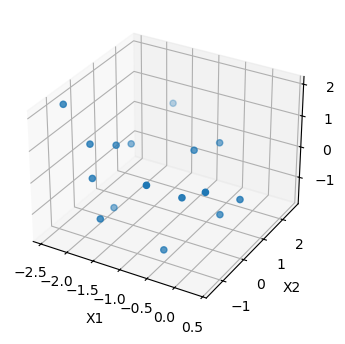

In [3]:
# 3d scatter plot
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2])
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("X3")

Text(0, 0.5, 'X3')

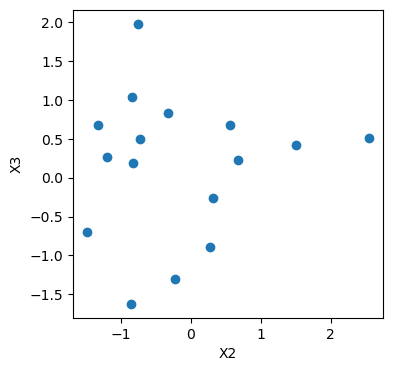

In [4]:
# 2d scatter plot on X_{-j} (excluding the j-th feature)
fig = plt.figure(figsize=(4, 4))
plt.scatter(X.iloc[:, 1], X.iloc[:, 2])
plt.xlabel("X2")
plt.ylabel("X3")


In [5]:
K = bin_selection(n)
feature_idx = 1
x = X.iloc[:, feature_idx - 1]
edges = np.quantile(x, np.linspace(0, 1, K + 1))
edges[0], edges[-1] = x.min(), x.max() + np.finfo(np.float16).eps
paths = generate_connected_paths(X, feature_idx, edges)


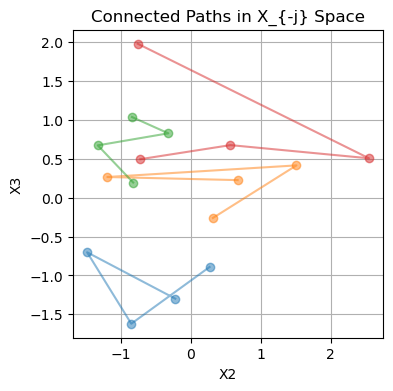

In [6]:
# for each path, plot the path in X_{-j} space
plt.figure(figsize=(4, 4))
for path in paths:
    path_X = path.drop(path.columns[feature_idx - 1], axis=1)
    plt.plot(path_X.iloc[:, 0], path_X.iloc[:, 1], marker="o", linestyle="-", alpha=0.5)
plt.xlabel("X2")
plt.ylabel("X3")
plt.title("Connected Paths in X_{-j} Space")
plt.grid()
plt.show()


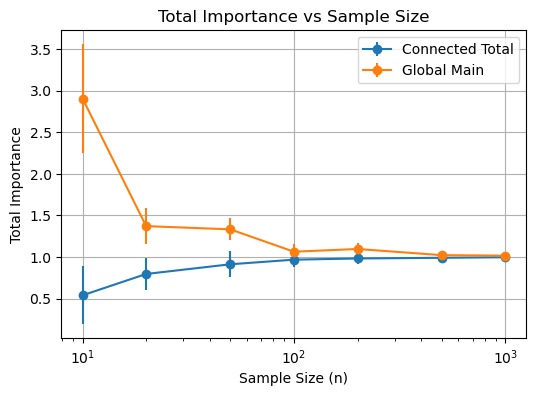

In [ ]:
n_vec = np.array([10, 20, 50, 100, 200, 500, 1000])
replications = 20
ale_connected_total_vals = np.zeros((len(n_vec), replications))
ale_global_main_vals = np.zeros((len(n_vec), replications))

for i, n in enumerate(n_vec):
    for r in range(replications):
        X = pd.DataFrame(generate_3d_data_uniform(n, sigma=0.5), columns=["X1","X2","X3"])
        f_lambda = lambda df: df.apply(lambda row: f(row.values), axis=1).to_numpy()
        K = bin_selection(n)
        feature_idx = 1
        ale_connected_total_vals[i, r] = ale_connected_total(f_lambda, X, feature_idx, bins=K)
        ale_global_main_vals[i, r] = ale_global_main(f_lambda, X, feature_idx, bins=K)

# plot mean and std of ale_connected_total_vals and ale_global_main_vals
mean_connected = np.mean(ale_connected_total_vals, axis=1)
std_connected = np.std(ale_connected_total_vals, axis=1)
mean_global = np.mean(ale_global_main_vals, axis=1)
std_global = np.std(ale_global_main_vals, axis=1)

plt.figure(figsize=(6, 4))
plt.errorbar(n_vec, mean_connected, yerr=std_connected, label="Connected Total", marker="o")
plt.errorbar(n_vec, mean_global, yerr=std_global, label="Global Main", marker="o")
plt.xscale("log")
plt.xlabel("Sample Size (n)")
plt.ylabel("Total Importance")
plt.title("Total Importance vs Sample Size for Uniform Model")
plt.legend()
plt.grid()
plt.show()
